# Day 4 — AI Model Training Phase 1
**Civic Sense Portal · MobileNetV2 Transfer Learning**

| Property | Value |
|----------|-------|
| Model | MobileNetV2 (ImageNet pre-trained) |
| Classes | `garbage` · `pothole` · `road_damage` |
| Input size | 224 × 224 RGB |
| Batch size | 32 |
| Epochs | 15 (Phase 1 — frozen base) |
| Dataset | `ai-service/data/unified/split/` |

**Goal:** fit the custom classification head while the MobileNetV2 backbone
stays frozen. Produces `models/mobilenetv2_phase1.keras` at the end.

## 1 · Imports & Environment

In [1]:
import os
import sys
import pathlib
import warnings
import importlib

# Suppress verbose TensorFlow/oneDNN messages
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 110

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import sklearn.utils

# Add scripts/ to path so we can import augment_pipeline
SCRIPTS_DIR = pathlib.Path("../scripts").resolve()
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

import augment_pipeline
importlib.reload(augment_pipeline)   # ensure latest version of the script is used

from augment_pipeline import (
    AlbumentationsDataset,
    CLASS_NAMES,
    CLASS_TO_IDX,
    IMG_SIZE,
    IMAGENET_MEAN,
    IMAGENET_STD,
)

print(f"TensorFlow  : {tf.__version__}")
print(f"Keras       : {keras.__version__}")
print(f"NumPy       : {np.__version__}")
print(f"Classes     : {CLASS_NAMES}")
print(f"IMG_SIZE    : {IMG_SIZE}")

# GPU info
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs available: {len(gpus)} → {[g.name for g in gpus]}")
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
else:
    print("  Training on CPU.")


TensorFlow  : 2.20.0
Keras       : 3.13.2
NumPy       : 2.4.2
Classes     : ['garbage', 'pothole', 'road_damage']
IMG_SIZE    : 224
GPUs available: 1 → ['/physical_device:GPU:0']


## 2 · Configuration

In [2]:
# ── Paths ────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR = pathlib.Path(".").resolve()
AI_SERVICE   = NOTEBOOK_DIR.parent
DATA_ROOT    = AI_SERVICE / "data" / "unified" / "split"
MODELS_DIR   = AI_SERVICE / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Data root   : {DATA_ROOT}")
print(f"Models dir  : {MODELS_DIR}")

# Confirm split directories exist
for split in ("train", "val", "test"):
    p = DATA_ROOT / split
    exists = p.is_dir()
    counts = {c: len(list((p/c).glob("*"))) for c in CLASS_NAMES if (p/c).is_dir()} if exists else {}
    print(f"  {split:5s}/ → {'OK' if exists else 'MISSING':8s}  {counts}")

# ── Hyperparameters ──────────────────────────────────────────────────────────
BATCH_SIZE   = 32
IMG_SHAPE    = (IMG_SIZE, IMG_SIZE, 3)
N_CLASSES    = len(CLASS_NAMES)
EPOCHS_P1    = 15        # Phase 1: frozen backbone
LR_P1        = 1e-3      # Adam lr for Phase 1
SEED         = 42
DROPOUT_RATE = 0.4

# Model checkpoint path
CKPT_PATH    = MODELS_DIR / "mobilenetv2_phase1.keras"
BEST_CKPT    = MODELS_DIR / "mobilenetv2_best.keras"
LOG_CSV      = MODELS_DIR / "training_log_phase1.csv"

print(f"\nBatch size  : {BATCH_SIZE}")
print(f"Epochs (P1) : {EPOCHS_P1}")
print(f"LR (P1)     : {LR_P1}")
print(f"Checkpoint  : {CKPT_PATH}")

Data root   : /mnt/c/Users/ayush/Programs/Civic Sense Portal/ai-service/data/unified/split
Models dir  : /mnt/c/Users/ayush/Programs/Civic Sense Portal/ai-service/models
  train/ → OK        {'garbage': 1750, 'pothole': 1250, 'road_damage': 1750}
  val  / → OK        {'garbage': 375, 'pothole': 267, 'road_damage': 375}
  test / → OK        {'garbage': 375, 'pothole': 269, 'road_damage': 375}

Batch size  : 32
Epochs (P1) : 15
LR (P1)     : 0.001
Checkpoint  : /mnt/c/Users/ayush/Programs/Civic Sense Portal/ai-service/models/mobilenetv2_phase1.keras


## 3 · Data Loading Pipeline

We use **two complementary pipelines**:

| Split | Pipeline | Augmentation |
|-------|----------|--------------|
| `train` | `tf.data` via `AlbumentationsDataset` | Full (class-specific Albumentations) |
| `val` | `ImageDataGenerator` | Rescale only |
| `test` | `ImageDataGenerator` | Rescale only |

In [3]:
# ── Class weights (compensate pothole imbalance) ──────────────────────────────
from sklearn.utils.class_weight import compute_class_weight

TRAIN_COUNTS = {"garbage": 1750, "pothole": 1250, "road_damage": 1750}   # from Day 3
y_labels = (
    ["garbage"] * TRAIN_COUNTS["garbage"]
    + ["pothole"]    * TRAIN_COUNTS["pothole"]
    + ["road_damage"] * TRAIN_COUNTS["road_damage"]
)
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array(CLASS_NAMES),
    y=y_labels,
)
CLASS_WEIGHTS = dict(enumerate(weights))

print("Class weights:")
for idx, name in enumerate(CLASS_NAMES):
    print(f"  [{idx}] {name:12s} → {CLASS_WEIGHTS[idx]:.4f}")

Class weights:
  [0] garbage      → 0.9048
  [1] pothole      → 1.2667
  [2] road_damage  → 0.9048


In [4]:
# ── Training tf.data pipeline (Albumentations augmentation) ──────────────────

def make_tf_dataset(
    split: str,
    augment: bool,
    batch_size: int = BATCH_SIZE,
    repeat: bool = False,
) -> tf.data.Dataset:
    """Build a tf.data.Dataset from AlbumentationsDataset."""
    alb_ds = AlbumentationsDataset(
        DATA_ROOT / split,
        augment=augment,
        shuffle=(split == "train"),
        seed=SEED,
    )
    print(f"  [{split:5s}] total={len(alb_ds)}  counts={alb_ds.class_counts()}")

    def generator():
        yield from alb_ds

    ds = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=IMG_SHAPE, dtype=tf.float32),
            tf.TensorSpec(shape=(),       dtype=tf.int32),
        ),
    )

    if repeat:
        ds = ds.repeat()

    ds = (
        ds
        .batch(batch_size, drop_remainder=False)
        .prefetch(tf.data.AUTOTUNE)
    )
    return ds, len(alb_ds)


print("Building datasets...")
train_ds, n_train = make_tf_dataset("train", augment=True,  repeat=True)
val_ds,   n_val   = make_tf_dataset("val",   augment=False, repeat=False)
test_ds,  n_test  = make_tf_dataset("test",  augment=False, repeat=False)

STEPS_PER_EPOCH      = int(np.ceil(n_train / BATCH_SIZE))
VALIDATION_STEPS     = int(np.ceil(n_val   / BATCH_SIZE))

print(f"\nSteps/epoch : {STEPS_PER_EPOCH}")
print(f"Val steps   : {VALIDATION_STEPS}")

Building datasets...
  [train] total=4750  counts={'garbage': 1750, 'pothole': 1250, 'road_damage': 1750}


I0000 00:00:1772698631.541263    1045 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


  [val  ] total=1017  counts={'garbage': 375, 'pothole': 267, 'road_damage': 375}
  [test ] total=1019  counts={'garbage': 375, 'pothole': 269, 'road_damage': 375}

Steps/epoch : 149
Val steps   : 32


## 4 · Visualise Sample Augmented Batches

Quick sanity check — display one batch of 8 training images per class.

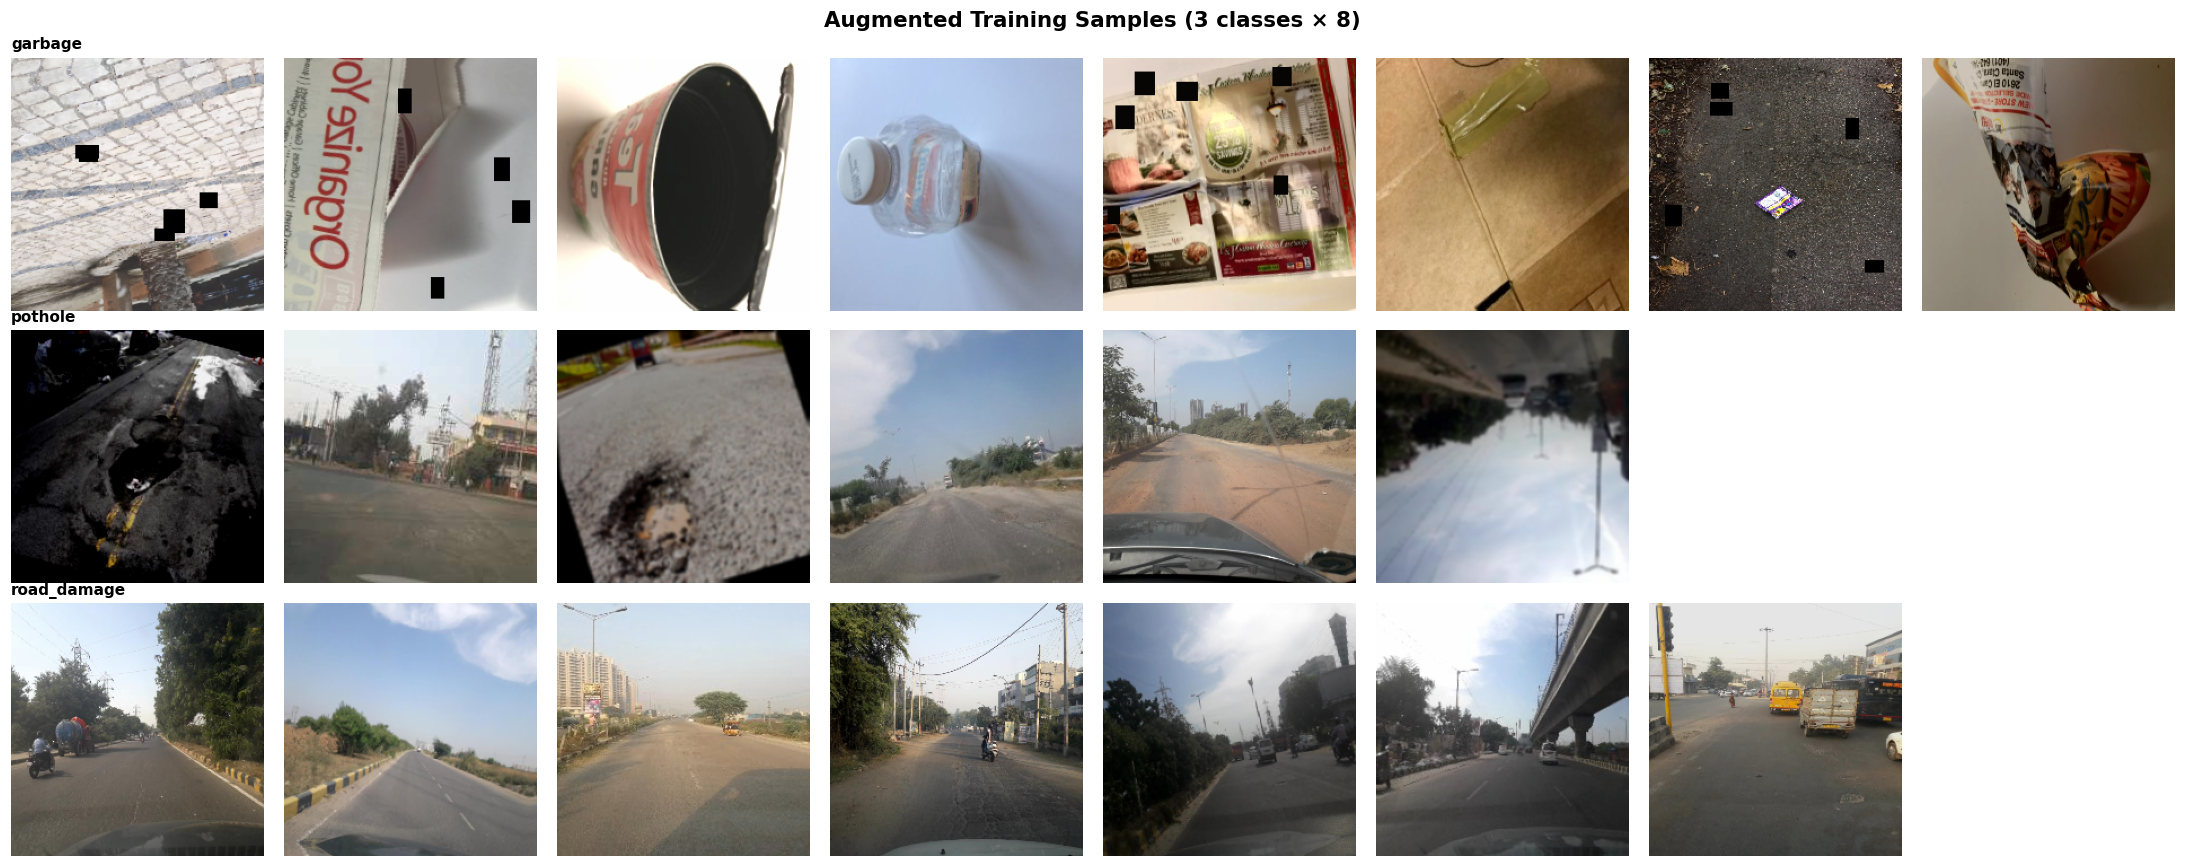

In [5]:
def denormalize(img: np.ndarray) -> np.ndarray:
    """Reverse ImageNet normalisation for display."""
    mean = np.array(IMAGENET_MEAN)
    std  = np.array(IMAGENET_STD)
    img = img * std + mean
    return np.clip(img, 0, 1)


# Grab one batch from training set for visualisation
sample_images, sample_labels = next(iter(train_ds.unbatch().batch(24)))
sample_images = sample_images.numpy()
sample_labels = sample_labels.numpy()

fig, axes = plt.subplots(3, 8, figsize=(20, 8))
fig.suptitle("Augmented Training Samples (3 classes × 8)", fontsize=14, fontweight="bold")

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    cls_imgs = sample_images[sample_labels == cls_idx]
    for col in range(8):
        ax = axes[cls_idx][col]
        if col < len(cls_imgs):
            ax.imshow(denormalize(cls_imgs[col]))
        ax.axis("off")
        if col == 0:
            ax.set_title(cls_name, fontsize=10, fontweight="bold", loc="left")

plt.tight_layout()
plt.savefig(MODELS_DIR / "sample_augmented_train.png", bbox_inches="tight")
plt.show()

## 5 · Build Model

**Architecture:**
```
MobileNetV2 (frozen, ImageNet weights)
     ↓
Global Average Pooling 2D
     ↓
Dense(256, ReLU) + BatchNorm + Dropout(0.4)
     ↓
Dense(128, ReLU) + BatchNorm + Dropout(0.2)
     ↓
Dense(3, Softmax)  — garbage / pothole / road_damage
```

In [6]:
def build_model(n_classes: int = N_CLASSES, dropout: float = DROPOUT_RATE) -> keras.Model:
    """MobileNetV2 backbone + custom classification head."""
    # ── Backbone ─────────────────────────────────────────────────────────────
    backbone = MobileNetV2(
        input_shape=IMG_SHAPE,
        include_top=False,          # remove original 1000-class head
        weights="imagenet",
    )
    backbone.trainable = False      # freeze ALL backbone layers for Phase 1

    # ── Custom head ──────────────────────────────────────────────────────────
    inputs = keras.Input(shape=IMG_SHAPE, name="image_input")
    x = backbone(inputs, training=False)   # training=False keeps BN in inference mode

    x = layers.GlobalAveragePooling2D(name="gap")(x)

    x = layers.Dense(256, name="fc1")(x)
    x = layers.BatchNormalization(name="bn1")(x)
    x = layers.Activation("relu",   name="relu1")(x)
    x = layers.Dropout(dropout,     name="drop1")(x)

    x = layers.Dense(128, name="fc2")(x)
    x = layers.BatchNormalization(name="bn2")(x)
    x = layers.Activation("relu",   name="relu2")(x)
    x = layers.Dropout(dropout / 2, name="drop2")(x)

    outputs = layers.Dense(n_classes, activation="softmax", name="predictions")(x)

    model = keras.Model(inputs, outputs, name="civic_classifier_v1")
    return model


model = build_model()
model.summary(show_trainable=True, expand_nested=False)

trainable_params   = sum(p.numpy().size for p in model.trainable_weights)
total_params       = sum(p.numpy().size for p in model.weights)
print(f"\nTrainable params : {trainable_params:,}  ({100*trainable_params/total_params:.1f}%)")
print(f"Frozen params    : {total_params - trainable_params:,}")

Model: "civic_classifier_v1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ image_input (InputLayer)    │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ mobilenetv2_1.00_224        │ (None, 7, 7, 1280)    │  2,257,984 │   N   │
│ (Functional)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ gap                         │ (None, 1280)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ fc1 (Dense)                 │ (None, 256)           │    327,936 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ bn1 (BatchNormalization)    │ (None, 256)           │      1,024 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ relu1 (Activation)          │ (None, 256)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ drop1 (Dropout)             │ (None, 256)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ fc2 (Dense)                 │ (None, 128)           │     32,896 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ bn2 (BatchNormalization)    │ (None, 128)           │        512 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ relu2 (Activation)          │ (None, 128)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ drop2 (Dropout)             │ (None, 128)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ predictions (Dense)         │ (None, 3)             │        387 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 2,620,739 (10.00 MB)

 Trainable params: 361,987 (1.38 MB)

 Non-trainable params: 2,258,752 (8.62 MB)


Trainable params : 361,987  (13.8%)
Frozen params    : 2,258,752


## 6 · Compile

In [7]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_P1),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
        keras.metrics.SparseTopKCategoricalAccuracy(k=2, name="top2_acc"),
    ],
)

print(f"Optimizer : Adam  lr={LR_P1}")
print(f"Loss      : SparseCategoricalCrossentropy")
print(f"Metric    : accuracy, top2_acc")

Optimizer : Adam  lr=0.001
Loss      : SparseCategoricalCrossentropy
Metric    : accuracy, top2_acc


## 7 · Callbacks

In [8]:
callbacks = [
    # Save best model by val_accuracy
    keras.callbacks.ModelCheckpoint(
        filepath    = str(BEST_CKPT),
        monitor     = "val_accuracy",
        save_best_only = True,
        mode        = "max",
        verbose     = 1,
    ),
    # Reduce LR when val_loss plateaus
    keras.callbacks.ReduceLROnPlateau(
        monitor   = "val_loss",
        factor    = 0.4,
        patience  = 3,
        min_lr    = 1e-6,
        verbose   = 1,
    ),
    # Stop early if no improvement for 5 epochs
    keras.callbacks.EarlyStopping(
        monitor   = "val_accuracy",
        patience  = 5,
        restore_best_weights = True,
        verbose   = 1,
    ),
    # CSV log
    keras.callbacks.CSVLogger(
        str(LOG_CSV),
        separator = ",",
        append    = False,
    ),
    # TensorBoard (optional — run `tensorboard --logdir ai-service/models/tb_logs`)
    keras.callbacks.TensorBoard(
        log_dir   = str(MODELS_DIR / "tb_logs" / "phase1"),
        histogram_freq = 1,
        write_graph    = False,
    ),
]

print("Callbacks registered:")
for cb in callbacks:
    print(f"  · {type(cb).__name__}")

Callbacks registered:
  · ModelCheckpoint
  · ReduceLROnPlateau
  · EarlyStopping
  · CSVLogger
  · TensorBoard


## 8 · Train — Phase 1 (frozen backbone)

Only the custom head is trained here. The MobileNetV2 backbone stays frozen.
Target: **≥ 80% val_accuracy** by epoch 15 before moving to Phase 2 fine-tuning (Day 5).

In [9]:
print("=" * 60)
print(" PHASE 1 — Training custom head (backbone frozen)")
print(f" Epochs       : {EPOCHS_P1}")
print(f" Steps/epoch  : {STEPS_PER_EPOCH}")
print(f" Batch size   : {BATCH_SIZE}")
print(f" Train samples: {n_train}")
print(f" Val samples  : {n_val}")
print("=" * 60)

history = model.fit(
    train_ds,
    steps_per_epoch  = STEPS_PER_EPOCH,
    epochs           = EPOCHS_P1,
    validation_data  = val_ds,
    validation_steps = VALIDATION_STEPS,
    class_weight     = CLASS_WEIGHTS,
    callbacks        = callbacks,
    verbose          = 1,
)

 PHASE 1 — Training custom head (backbone frozen)
 Epochs       : 15
 Steps/epoch  : 149
 Batch size   : 32
 Train samples: 4750
 Val samples  : 1017
Epoch 1/15


2026-03-05 08:18:46.805789: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng5{} for conv (f32[32,32,112,112]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,32,112,112]{3,2,1,0}, f32[32,1,3,3]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, feature_group_count=32, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-03-05 08:18:46.807377: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 6.995686073s
Trying algorithm eng5{} for conv (f32[32,32,112,112]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,32,112,112]{3,2,1,0}, f32[32,1,3,3]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, feature_group_count=32, custom_call_target="__cudnn$convForwa

149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8013 - loss: 0.5066 - top2_acc: 0.9587

2026-03-05 08:22:37.177890: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng46{k2=1,k5=3,k14=2} for conv (f32[25,32,28,28]{3,2,1,0}, u8[0]{0}) custom-call(f32[25,144,28,28]{3,2,1,0}, f32[32,144,1,1]{3,2,1,0}), window={size=1x1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-03-05 08:22:37.180146: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 6.980635549s
Trying algorithm eng46{k2=1,k5=3,k14=2} for conv (f32[25,32,28,28]{3,2,1,0}, u8[0]{0}) custom-call(f32[25,144,28,28]{3,2,1,0}, f32[32,144,1,1]{3,2,1,0}), window={size=1x1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":


Epoch 1: val_accuracy improved from None to 0.83776, saving model to /mnt/c/Users/ayush/Programs/Civic Sense Portal/ai-service/models/mobilenetv2_best.keras

Epoch 1: finished saving model to /mnt/c/Users/ayush/Programs/Civic Sense Portal/ai-service/models/mobilenetv2_best.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 259s 2s/step - accuracy: 0.8607 - loss: 0.3804 - top2_acc: 0.9864 - val_accuracy: 0.8378 - val_loss: 0.3724 - val_top2_acc: 0.9990 - learning_rate: 0.0010
Epoch 2/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 839ms/step - accuracy: 0.9029 - loss: 0.2685 - top2_acc: 0.9985
Epoch 2: val_accuracy improved from 0.83776 to 0.84759, saving model to /mnt/c/Users/ayush/Programs/Civic Sense Portal/ai-service/models/mobilenetv2_best.keras

Epoch 2: finished saving model to /mnt/c/Users/ayush/Programs/Civic Sense Portal/ai-service/models/mobilenetv2_best.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 159s 1s/step - accuracy: 0.9039 - loss: 0.2665 - top2_acc: 0.9977 - val_accuracy: 0.8476 - val_loss: 0.3904 - val_to

## 9 · Training Curves

Saved to /mnt/c/Users/ayush/Programs/Civic Sense Portal/ai-service/models/phase1_training_curves.png


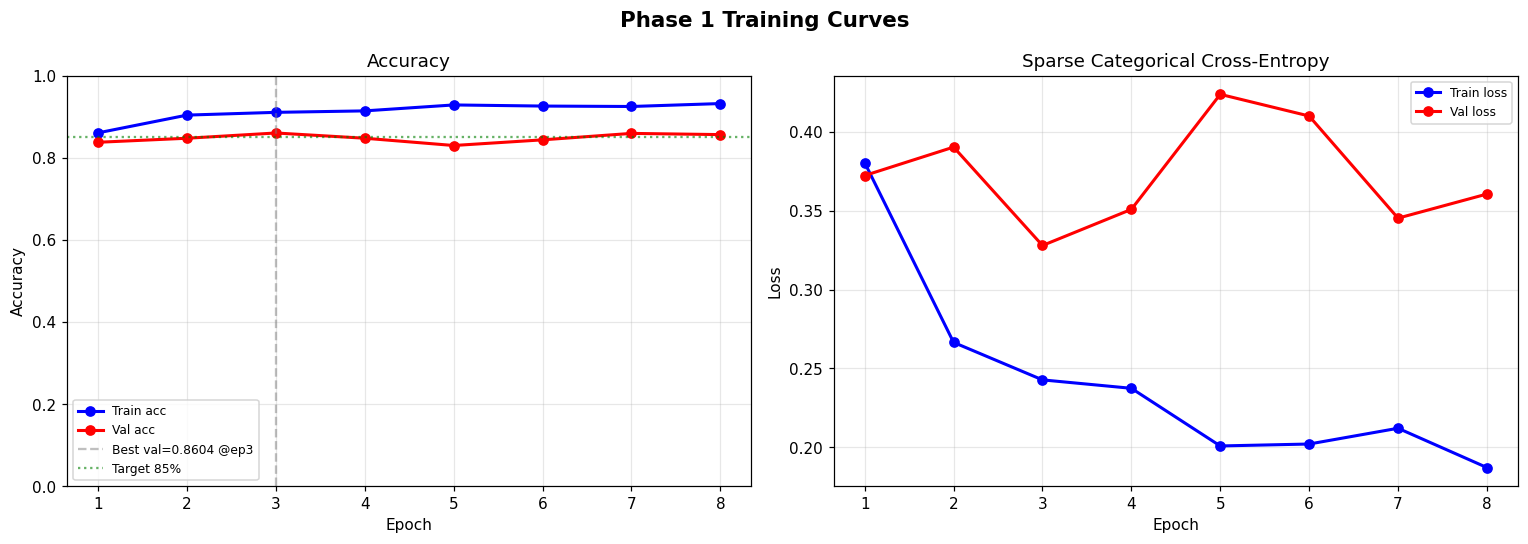

In [10]:
def plot_history(history: keras.callbacks.History, save_path=None):
    hist = history.history
    epochs_ran = range(1, len(hist["accuracy"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Phase 1 Training Curves", fontsize=14, fontweight="bold")

    # ── Accuracy ─────────────────────────────────────────────────────────────
    ax = axes[0]
    ax.plot(epochs_ran, hist["accuracy"],     "b-o", label="Train acc",  linewidth=2)
    ax.plot(epochs_ran, hist["val_accuracy"], "r-o", label="Val acc",    linewidth=2)
    best_val_acc = max(hist["val_accuracy"])
    best_ep      = hist["val_accuracy"].index(best_val_acc) + 1
    ax.axvline(best_ep, color="gray", linestyle="--", alpha=0.5, label=f"Best val={best_val_acc:.4f} @ep{best_ep}")
    ax.axhline(0.85, color="green", linestyle=":", alpha=0.6, label="Target 85%")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.set_title("Accuracy")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1)

    # ── Loss ──────────────────────────────────────────────────────────────────
    ax = axes[1]
    ax.plot(epochs_ran, hist["loss"],     "b-o", label="Train loss", linewidth=2)
    ax.plot(epochs_ran, hist["val_loss"], "r-o", label="Val loss",   linewidth=2)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title("Sparse Categorical Cross-Entropy")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
        print(f"Saved to {save_path}")
    plt.show()


plot_history(history, save_path=MODELS_DIR / "phase1_training_curves.png")

## 10 · Evaluate on Validation Set (per-class)

Classification Report — Validation Set
              precision    recall  f1-score   support

     garbage       0.97      0.97      0.97       375
     pothole       0.85      0.57      0.68       267
 road_damage       0.78      0.96      0.86       375

    accuracy                           0.86      1017
   macro avg       0.87      0.83      0.84      1017
weighted avg       0.87      0.86      0.85      1017



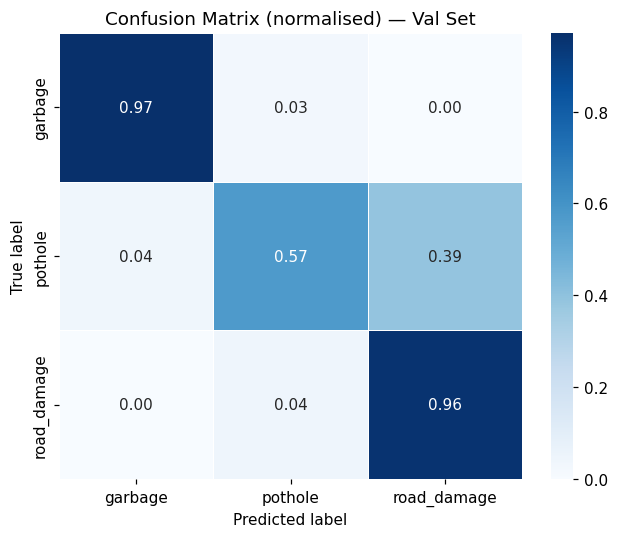

In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Collect predictions on validation split
y_true, y_pred = [], []
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy().tolist())
    y_pred.extend(np.argmax(preds, axis=1).tolist())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Classification Report — Validation Set")
print("=" * 55)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# Confusion matrix heat-map
cm = confusion_matrix(y_true, y_pred, normalize="true")
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt=".2f", cmap="Blues",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=0.5, ax=ax,
)
ax.set_title("Confusion Matrix (normalised) — Val Set")
ax.set_ylabel("True label")
ax.set_xlabel("Predicted label")
plt.tight_layout()
plt.savefig(MODELS_DIR / "phase1_confusion_matrix.png", bbox_inches="tight")
plt.show()

## 11 · Save Model Checkpoints

In [13]:
# Save final epoch model (may differ from best)
model.save(str(CKPT_PATH))
print(f"Phase 1 final model → {CKPT_PATH}")

# The best-val-accuracy model was already saved by ModelCheckpoint callback
print(f"Best val-acc model  → {BEST_CKPT}")
print(f"Training CSV log    → {LOG_CSV}")

# Summary table
hist = history.history
best_val_acc  = max(hist["val_accuracy"])
best_ep       = hist["val_accuracy"].index(best_val_acc) + 1
final_val_acc = hist["val_accuracy"][-1]
final_ep      = len(hist["val_accuracy"])

print("\n" + "=" * 50)
print(" Phase 1 Training Summary")
print("=" * 50)
print(f"  Total epochs run   : {final_ep}")
print(f"  Best val_accuracy  : {best_val_acc:.4f}  (epoch {best_ep})")
print(f"  Final val_accuracy : {final_val_acc:.4f}  (epoch {final_ep})")
print(f"  Best val_loss      : {min(hist['val_loss']):.4f}")
print("=" * 50)

if best_val_acc >= 0.85:
    print("✅ Target ≥85% val_accuracy reached")
else:
    remaining = 0.85 - best_val_acc
    print(f"⚠️  Val accuracy {best_val_acc:.2%} — {remaining:.2%} below target.")
    print("   Consider: more epochs / lower LR / check augmentation pipeline.")

Phase 1 final model → /mnt/c/Users/ayush/Programs/Civic Sense Portal/ai-service/models/mobilenetv2_phase1.keras
Best val-acc model  → /mnt/c/Users/ayush/Programs/Civic Sense Portal/ai-service/models/mobilenetv2_best.keras
Training CSV log    → /mnt/c/Users/ayush/Programs/Civic Sense Portal/ai-service/models/training_log_phase1.csv

 Phase 1 Training Summary
  Total epochs run   : 8
  Best val_accuracy  : 0.8604  (epoch 3)
  Final val_accuracy : 0.8564  (epoch 8)
  Best val_loss      : 0.3280
✅ Target ≥85% val_accuracy reached


## 12 · Quick Inference Test

2026-03-05 08:49:58.712400: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng3{k11=2} for conv (f32[1,576,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[1,576,14,14]{3,2,1,0}, f32[576,1,3,3]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, feature_group_count=576, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-03-05 08:49:58.726229: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.033947897s
Trying algorithm eng3{k11=2} for conv (f32[1,576,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[1,576,14,14]{3,2,1,0}, f32[576,1,3,3]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, feature_group_count=576, custom_call_target="__cudnn$con

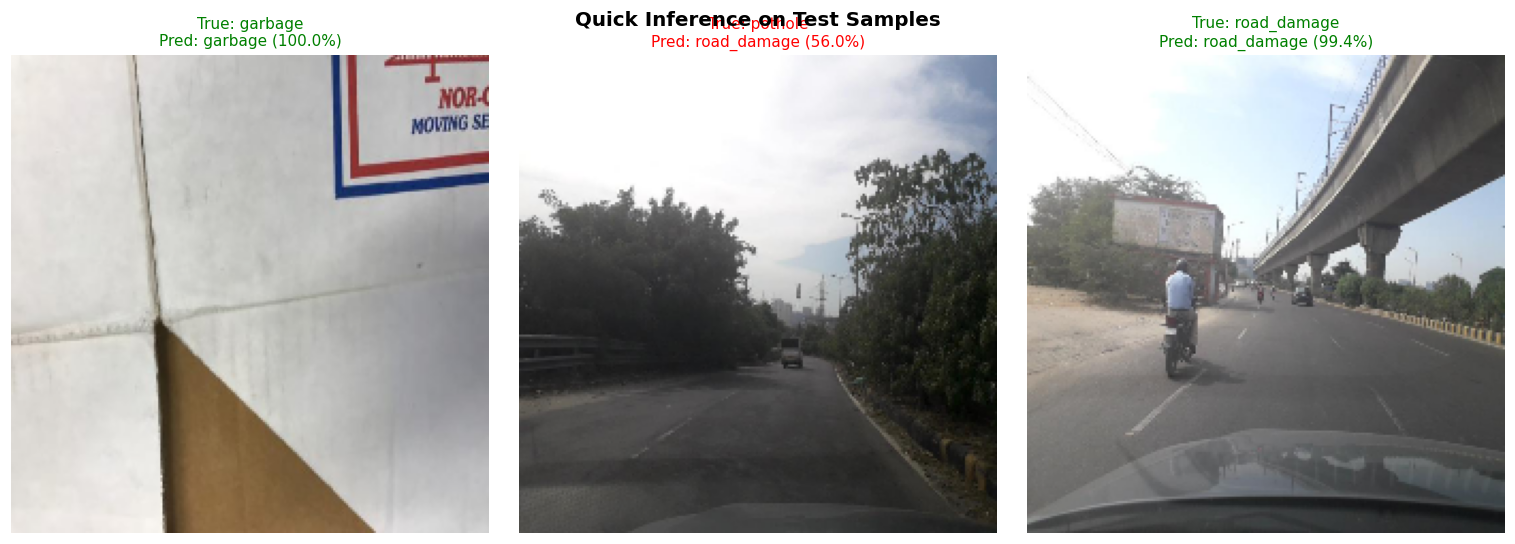

In [14]:
from augment_pipeline import get_val_test_transforms
import cv2

def predict_image(img_path: str | pathlib.Path, model: keras.Model) -> dict:
    """Run inference on a single image and return label + confidence."""
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    transform = get_val_test_transforms()
    img = transform(image=img)["image"].astype(np.float32)
    img_batch = np.expand_dims(img, axis=0)   # (1, 224, 224, 3)
    probs = model.predict(img_batch, verbose=0)[0]
    predicted_idx = int(np.argmax(probs))
    return {
        "predicted_class" : CLASS_NAMES[predicted_idx],
        "confidence"      : float(probs[predicted_idx]),
        "all_probs"       : {cls: float(p) for cls, p in zip(CLASS_NAMES, probs)},
    }


# Find one sample image from each test class
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Quick Inference on Test Samples", fontsize=13, fontweight="bold")

for ax, cls_name in zip(axes, CLASS_NAMES):
    cls_dir = DATA_ROOT / "test" / cls_name
    imgs = sorted(cls_dir.glob("*.jpg"))[:1] + sorted(cls_dir.glob("*.jpeg"))[:1] + sorted(cls_dir.glob("*.png"))[:1]
    if not imgs:
        ax.set_title(f"{cls_name}\n(no images found)")
        ax.axis("off")
        continue
    img_path = imgs[0]
    result   = predict_image(img_path, model)

    raw = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    raw = cv2.resize(raw, (224, 224))
    ax.imshow(raw)
    ax.axis("off")
    colour = "green" if result["predicted_class"] == cls_name else "red"
    ax.set_title(
        f"True: {cls_name}\n"
        f"Pred: {result['predicted_class']} ({result['confidence']:.1%})",
        color=colour, fontsize=10
    )

plt.tight_layout()
plt.savefig(MODELS_DIR / "phase1_inference_test.png", bbox_inches="tight")
plt.show()

## 13 · Next Steps (Day 5)

| Step | Action |
|------|--------|
| Fine-tuning | Unfreeze top ~30 layers of MobileNetV2, train with lower LR (1e-5) |
| Evaluation | Full classification report on **test** set |
| Severity model | Add regression head for severity scoring (separate training pass) |
| Export | Save as `.keras`, `.h5`, and TFLite format |
| FastAPI | Wrap model in `/predict` endpoint (Day 6) |

Model files written:
- `ai-service/models/mobilenetv2_phase1.keras` — final epoch weights
- `ai-service/models/mobilenetv2_best.keras` — best val_accuracy weights
- `ai-service/models/training_log_phase1.csv` — per-epoch metrics
- `ai-service/models/phase1_training_curves.png` — accuracy/loss plots
- `ai-service/models/phase1_confusion_matrix.png` — normalised confusion matrix